<a href="https://colab.research.google.com/github/adilawan1/deep-learning-assignment-3/blob/main/25280033_AI_600_PA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 3
# Ahmed Adil
# 25280033

#Task 1 Part A

##1 and 2

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


Total Parameters: 26698
Epoch 1/10 | Train Acc: 89.14% | Val Acc: 96.29%
Epoch 2/10 | Train Acc: 96.94% | Val Acc: 97.80%
Epoch 3/10 | Train Acc: 97.70% | Val Acc: 97.32%
Epoch 4/10 | Train Acc: 98.12% | Val Acc: 98.00%
Epoch 5/10 | Train Acc: 98.37% | Val Acc: 98.39%
Epoch 6/10 | Train Acc: 98.68% | Val Acc: 98.37%
Epoch 7/10 | Train Acc: 98.77% | Val Acc: 98.37%
Epoch 8/10 | Train Acc: 98.92% | Val Acc: 98.33%
Epoch 9/10 | Train Acc: 99.05% | Val Acc: 98.66%
Epoch 10/10 | Train Acc: 99.17% | Val Acc: 98.58%


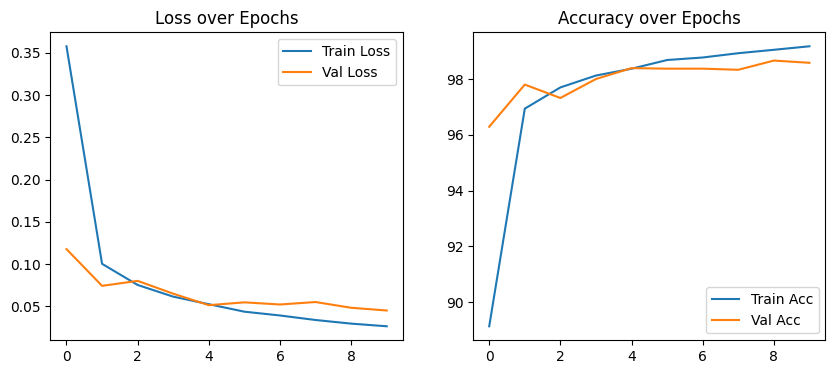

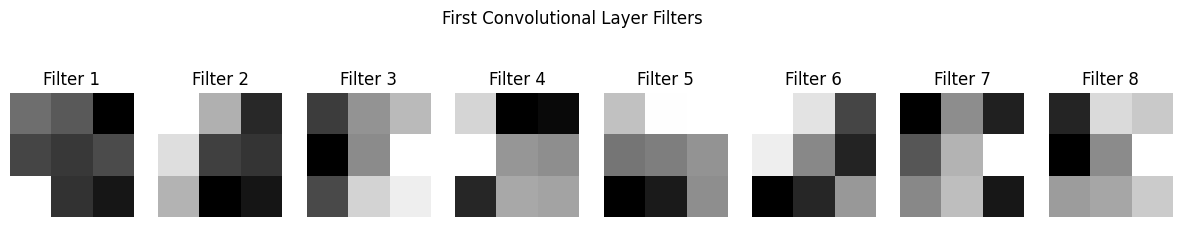

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

class ToyCNN_MNIST(nn.Module):
    def __init__(self):
        super(ToyCNN_MNIST, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(16 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = ToyCNN_MNIST()
print(f"Total Parameters: {sum(p.numel() for p in model.parameters())}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# --- Training and Validation ---
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)


    model.eval() # Set model to evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accuracies[-1]:.2f}% | Val Acc: {val_accuracies[-1]:.2f}%")


# Plot 1: Loss Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot 2: Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

weights = model.conv1.weight.data.numpy()
fig, axes = plt.subplots(1, 8, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(weights[i, 0], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Filter {i+1}')
plt.suptitle('First Convolutional Layer Filters')
plt.show()

#Task 1 Part B

##1 and 2

In [2]:
!unzip cmnist.zip

Archive:  cmnist.zip
  inflating: test_biased.pt          
  inflating: __MACOSX/._test_biased.pt  
  inflating: test_unbiased.pt        
  inflating: __MACOSX/._test_unbiased.pt  
  inflating: train_biased.pt         
  inflating: __MACOSX/._train_biased.pt  


In [4]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    train_biased_data = torch.load('train_biased.pt',weights_only=False)
    test_biased_data = torch.load('test_biased.pt',weights_only=False)
    test_unbiased_data = torch.load('test_unbiased.pt',weights_only=False)

    train_biased_dataset = TensorDataset(train_biased_data[0], train_biased_data[1])
    test_biased_dataset = TensorDataset(test_biased_data[0], test_biased_data[1])
    test_unbiased_dataset = TensorDataset(test_unbiased_data[0], test_unbiased_data[1])

    train_biased_loader = DataLoader(train_biased_dataset, batch_size=64, shuffle=True)
    test_biased_loader = DataLoader(test_biased_dataset, batch_size=64, shuffle=False)
    test_unbiased_loader = DataLoader(test_unbiased_dataset, batch_size=64, shuffle=False)

except FileNotFoundError:
    print("Error: Please update the file paths to your LMS dataset files.")
    exit()


class ToyCNN_CMNIST(nn.Module):
    def __init__(self):
        super(ToyCNN_CMNIST, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(in_features=784, out_features=32)
        self.fc2 = nn.Linear(in_features=32, out_features=10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_cmnist = ToyCNN_CMNIST()
total_params = sum(p.numel() for p in model_cmnist.parameters())
print(f"Total Model Parameters: {total_params}")


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cmnist.parameters(), lr=0.001)

epochs = 10
print("\n--- Starting Training on Biased Dataset ---")
for epoch in range(epochs):
    model_cmnist.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_biased_loader:
        optimizer.zero_grad()

        outputs = model_cmnist(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {running_loss/len(train_biased_loader):.4f} | Train Acc: {train_acc:.2f}%")

def evaluate_model(model, test_loader, dataset_name):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy on {dataset_name}: {accuracy:.2f}%")
    return accuracy

print("\n--- Final Model Evaluation ---")
biased_acc = evaluate_model(model_cmnist, test_biased_loader, "Biased Test Set")
unbiased_acc = evaluate_model(model_cmnist, test_unbiased_loader, "Unbiased Test Set")

Total Model Parameters: 26842

--- Starting Training on Biased Dataset ---
Epoch 1/10 | Train Loss: 0.2928 | Train Acc: 92.48%
Epoch 2/10 | Train Loss: 0.1110 | Train Acc: 96.94%
Epoch 3/10 | Train Loss: 0.0783 | Train Acc: 97.74%
Epoch 4/10 | Train Loss: 0.0545 | Train Acc: 98.38%
Epoch 5/10 | Train Loss: 0.0413 | Train Acc: 98.73%
Epoch 6/10 | Train Loss: 0.0328 | Train Acc: 98.99%
Epoch 7/10 | Train Loss: 0.0265 | Train Acc: 99.21%
Epoch 8/10 | Train Loss: 0.0232 | Train Acc: 99.30%
Epoch 9/10 | Train Loss: 0.0198 | Train Acc: 99.37%
Epoch 10/10 | Train Loss: 0.0171 | Train Acc: 99.45%

--- Final Model Evaluation ---
Accuracy on Biased Test Set: 99.49%
Accuracy on Unbiased Test Set: 90.85%


#Task 2 Part A

##1,2,3 and 4

In [5]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4c73b452e86338f875c1d3cf43963ef9bd8b7515c8d45439d3ed70d3b0c774a7
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [6]:
from torchvision.models import resnet18, ResNet18_Weights
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


print("--- Downloading and Setting up STL-10 Dataset ---")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform)
test_dataset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 3
print(f"\n--- Starting Training on {device} ---")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.2f}%")

print("\n--- Final Model Evaluation on Test Set ---")
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test Accuracy: {100*correct/total:.2f}%")

--- Downloading and Setting up STL-10 Dataset ---


100%|██████████| 2.64G/2.64G [00:32<00:00, 82.0MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]



--- Starting Training on cuda:0 ---
Epoch 1/3 | Loss: 0.7232 | Acc: 82.30%
Epoch 2/3 | Loss: 0.2785 | Acc: 92.46%
Epoch 3/3 | Loss: 0.2132 | Acc: 94.06%

--- Final Model Evaluation on Test Set ---
Test Accuracy: 94.20%



--- Generating GradCAM Heatmaps ---


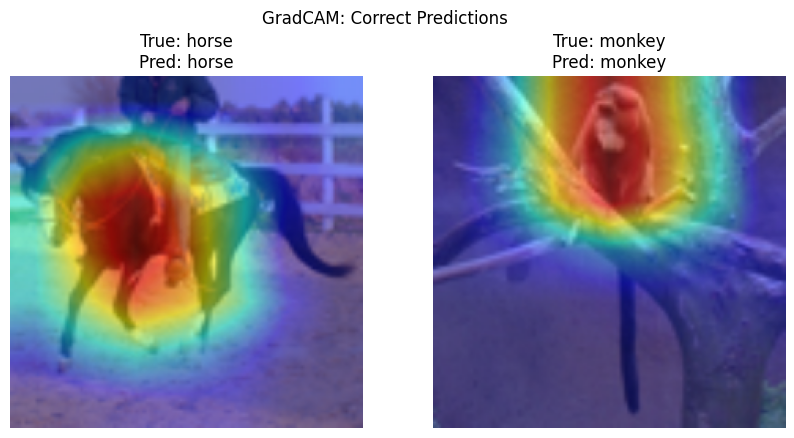

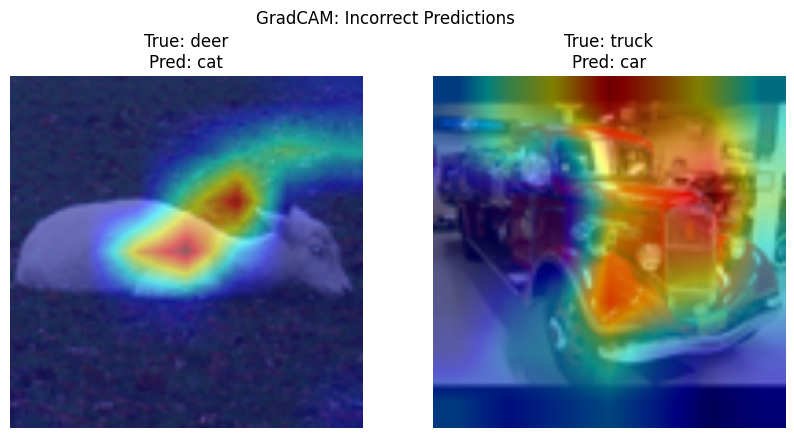

In [7]:
print("\n--- Generating GradCAM Heatmaps ---")

target_layers = [model.layer4[-1]]
for param in model.layer4[-1].parameters():
    param.requires_grad = True
cam = GradCAM(model=model, target_layers=target_layers)

classes = ('airplane', 'bird', 'car', 'cat', 'deer',
           'dog', 'horse', 'monkey', 'ship', 'truck')

correct_samples = []
incorrect_samples = []

model.eval()
for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    for i in range(inputs.size(0)):
        if preds[i] == labels[i] and len(correct_samples) < 2:
            correct_samples.append((inputs[i], labels[i], preds[i]))
        elif preds[i] != labels[i] and len(incorrect_samples) < 2:
            incorrect_samples.append((inputs[i], labels[i], preds[i]))

    if len(correct_samples) == 2 and len(incorrect_samples) == 2:
        break

def plot_gradcam(samples, title_prefix):
    fig, axes = plt.subplots(1, len(samples), figsize=(10, 5))
    for idx, (img_tensor, true_label, pred_label) in enumerate(samples):
        input_tensor = img_tensor.unsqueeze(0).to(device)

        targets = [ClassifierOutputTarget(true_label.item())]

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        img_for_vis = img_tensor.cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_for_vis = std * img_for_vis + mean
        img_for_vis = np.clip(img_for_vis, 0, 1)

        visualization = show_cam_on_image(img_for_vis, grayscale_cam, use_rgb=True)

        axes[idx].imshow(visualization)
        axes[idx].set_title(f"True: {classes[true_label]}\nPred: {classes[pred_label]}")
        axes[idx].axis('off')

    plt.suptitle(title_prefix)
    plt.show()

plot_gradcam(correct_samples, "GradCAM: Correct Predictions")
plot_gradcam(incorrect_samples, "GradCAM: Incorrect Predictions")